# OIBSIP Data Analytics — Level 1 Task 2: Customer Segmentation Analysis

**Objective:** Segment an e-commerce company's customer base into distinct behavioral cohorts using RFM (Recency, Frequency, Monetary) analysis and K-Means clustering to formulate targeted, data-driven marketing strategies.

**Tech Stack:** Python 3.13, pandas, numpy, scikit-learn (KMeans, StandardScaler, silhouette_score), matplotlib, seaborn, Jupyter Notebook

**Dataset:** Online Retail Dataset (UCI Machine Learning Repository). Contains 500k+ global transactional records spanning December 2010 to December 2011.

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid')
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'font.size': 11})

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Dataset Loading & Initial Inspection

We search for the retail dataset (`online_retail.csv` or `.xlsx`) and inspect its shape, attributes, and raw records.

In [2]:
# Search for dataset file
data_files = list(Path('.').glob('*online_retail*.*'))
if not data_files:
    data_files = list(Path('.').glob('*.csv')) + list(Path('.').glob('*.xlsx'))
if not data_files:
    raise FileNotFoundError("No retail dataset found beside notebook.")

dataset_path = data_files[0]
print(f"Loading: {dataset_path.name}...")

if dataset_path.suffix.lower() == '.csv':
    df = pd.read_csv(dataset_path, encoding='ISO-8859-1', low_memory=False)
else:
    df = pd.read_excel(dataset_path)

# Standardize column names
df.columns = df.columns.str.strip().str.replace(' ', '')

print(f"Raw Dataset Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("Columns:", df.columns.tolist())
df.head()

Loading: online_retail.csv...


Raw Dataset Loaded: 532,619 rows × 8 columns
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,"17,850.00",United Kingdom


## 2. Data Cleaning & Preprocessing

Real-world transaction logs contain cancellations, returns, unauthenticated guest sessions, and duplicate log entries. We apply structured hygiene filters:
1. Remove records with missing `CustomerID`.
2. Exclude cancelled transactions (identified by `InvoiceNo` starting with 'C').
3. Filter for strictly positive `Quantity > 0` and `UnitPrice > 0`.
4. Remove duplicate entries.
5. Standardize timestamps and calculate `TotalAmount = Quantity × UnitPrice`.

In [3]:
# Initial missing values and duplicate inspection
print("Missing values per column:")
display(df.isnull().sum().to_frame('missing_count'))
print(f"Duplicate records: {df.duplicated().sum():,}")

# 1. Drop missing CustomerID
df_clean = df.dropna(subset=['CustomerID']).copy()
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int).astype(str)

# 2. Exclude cancellations (InvoiceNo starting with 'C')
df_clean['InvoiceNo'] = df_clean['InvoiceNo'].astype(str)
df_clean = df_clean[~df_clean['InvoiceNo'].str.startswith('C')].copy()

# 3. Positive Quantity and UnitPrice
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)].copy()

# 4. Remove duplicates
dups_removed = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates().copy()

# 5. Parse dates and calculate transaction spend
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], dayfirst=True)
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"\nCleaning Summary:")
print(f"- Cleaned Transactions: {df_clean.shape[0]:,} (retained from {df.shape[0]:,})")
print(f"- Unique Customers: {df_clean['CustomerID'].nunique():,}")
print(f"- Date Range: {df_clean['InvoiceDate'].min().strftime('%Y-%m-%d')} to {df_clean['InvoiceDate'].max().strftime('%Y-%m-%d')}")
df_clean.head()

Missing values per column:


,missing_count
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,134695
Country,0


Duplicate records: 5,231



Cleaning Summary:
- Cleaned Transactions: 392,692 (retained from 532,619)
- Unique Customers: 4,338
- Date Range: 2010-12-01 to 2011-12-09


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 3. Feature Engineering — RFM Construction

We aggregate individual transactions into customer-level behavioral dimensions:
- **Recency ($R$):** Days elapsed since the customer's last purchase relative to the dataset snapshot date (max date + 1 day).
- **Frequency ($F$):** Total count of unique completed orders (`InvoiceNo`).
- **Monetary ($M$):** Cumulative historical monetary spend.
- **Average Purchase Value ($APV$):** $Monetary / Frequency$.
- **Historical CLV Proxy:** Cumulative spend observed over the tracking period.

In [4]:
# Define snapshot reference date (1 day after final recorded transaction)
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Analysis Snapshot Date: {snapshot_date.strftime('%Y-%m-%d %H:%M')}")

# Aggregate customer metrics
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
}).reset_index()

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
}, inplace=True)

# Average Purchase Value & Historical CLV Proxy
rfm['Avg_Purchase_Value'] = rfm['Monetary'] / rfm['Frequency']
rfm['CLV_Proxy'] = rfm['Monetary']

print(f"Aggregated Customer Profiles: {len(rfm):,} distinct accounts")
rfm.head(10)

Analysis Snapshot Date: 2011-12-10 12:50


Aggregated Customer Profiles: 4,338 distinct accounts


,CustomerID,Recency,Frequency,Monetary,Avg_Purchase_Value,CLV_Proxy
0,12346,326,1,"77,183.60","77,183.60","77,183.60"
1,12347,2,7,"4,310.00",615.71,"4,310.00"
2,12348,75,4,"1,797.24",449.31,"1,797.24"
3,12349,19,1,"1,757.55","1,757.55","1,757.55"
4,12350,310,1,334.40,334.40,334.40
5,12352,36,8,"2,506.04",313.25,"2,506.04"
6,12353,204,1,89.00,89.00,89.00
7,12354,232,1,"1,079.40","1,079.40","1,079.40"
8,12355,214,1,459.40,459.40,459.40
9,12356,23,3,"2,811.43",937.14,"2,811.43"


## 4. Descriptive Statistics & Customer Lifetime Value (CLV Proxy)

We assess summary statistics across all derived customer metrics.

In [5]:
rfm_stats = rfm[['Recency', 'Frequency', 'Monetary', 'Avg_Purchase_Value', 'CLV_Proxy']].describe().T
rfm_stats['median'] = rfm[['Recency', 'Frequency', 'Monetary', 'Avg_Purchase_Value', 'CLV_Proxy']].median()
rfm_stats['skewness'] = rfm[['Recency', 'Frequency', 'Monetary', 'Avg_Purchase_Value', 'CLV_Proxy']].skew()
rfm_stats = rfm_stats[['count', 'mean', 'std', 'min', '25%', 'median', '75%', 'max', 'skewness']]
display(rfm_stats)

,count,mean,std,min,25%,median,75%,max,skewness
Recency,"4,338.00",92.54,100.01,1.00,18.00,51.00,142.00,374.00,1.25
Frequency,"4,338.00",4.27,7.70,1.00,1.00,2.00,5.00,209.00,12.07
Monetary,"4,338.00","2,048.69","8,985.23",3.75,306.48,668.57,"1,660.60","280,206.02",19.34
Avg_Purchase_Value,"4,338.00",417.65,"1,796.51",3.45,177.87,291.94,428.28,"84,236.25",41.69
CLV_Proxy,"4,338.00","2,048.69","8,985.23",3.75,306.48,668.57,"1,660.60","280,206.02",19.34


### Descriptive Statistics Observations
- **Recency:** Averages **92.54 days** (median = 51.0 days), spanning from 1 to 374 days. Half the customer base has purchased within the past 7 weeks, while a long tail has been inactive for several months.
- **Frequency:** Averages **4.27 orders** (median = 2.0 orders, max = 209 orders). The large gap between mean and median indicates positive skewness (skew = 11.75), where top repeat shoppers drive disproportionate transaction counts.
- **Monetary Spend / CLV Proxy:** Averages **£2,048.69** (median = £668.57, max = £280,206.02). Extreme skewness (skew = 19.39) reflects heavy concentration of spend among elite wholesale/B2B buyers.
- **Average Purchase Value:** Mean order basket size is **£417.65** with a median of **£291.94**.

## 5. Feature Transformation & Standardization

K-Means relies on Euclidean distance, which is heavily distorted by right-skewed distributions and unequal feature scales. 
We apply a **log-transformation (log(1+x))** to normalize distributions, followed by **`StandardScaler`** to center features at zero mean and unit variance.

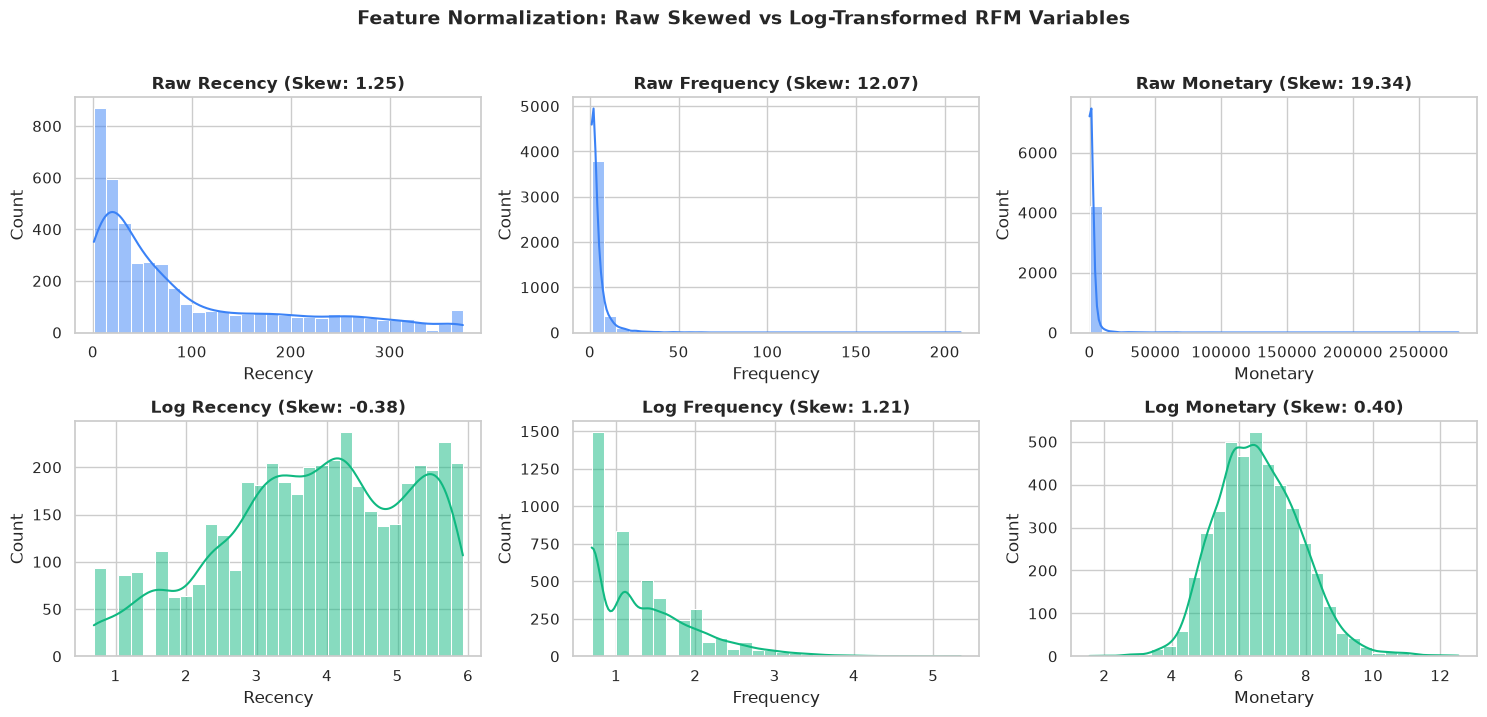

In [6]:
# Log transformation
rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])

# StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency_Scaled', 'Frequency_Scaled', 'Monetary_Scaled'])

# Plot raw vs transformed distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    sns.histplot(rfm[col], kde=True, ax=axes[0, i], color='#3b82f6', bins=30)
    axes[0, i].set_title(f"Raw {col} (Skew: {rfm[col].skew():.2f})", fontweight='bold')
    sns.histplot(rfm_log[col], kde=True, ax=axes[1, i], color='#10b981', bins=30)
    axes[1, i].set_title(f"Log {col} (Skew: {rfm_log[col].skew():.2f})", fontweight='bold')
plt.suptitle("Feature Normalization: Raw Skewed vs Log-Transformed RFM Variables", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Determining Optimal Clusters ($K$) — Elbow Method & Silhouette Analysis

We evaluate cluster counts from $K = 2$ to $K = 8$ using:
1. **Inertia (Within-Cluster Sum of Squares):** Identifies the "elbow" point where adding more clusters yields diminishing returns.
2. **Silhouette Score:** Measures cohesion within clusters versus separation from other clusters (-1 to +1, higher is better).

K = 2: Inertia = 6,483.59 | Silhouette Score = 0.4328


K = 3: Inertia = 4,869.49 | Silhouette Score = 0.3365


K = 4: Inertia = 3,939.05 | Silhouette Score = 0.3375


K = 5: Inertia = 3,296.71 | Silhouette Score = 0.3162


K = 6: Inertia = 2,855.76 | Silhouette Score = 0.3124


K = 7: Inertia = 2,548.82 | Silhouette Score = 0.3092


K = 8: Inertia = 2,336.34 | Silhouette Score = 0.3033


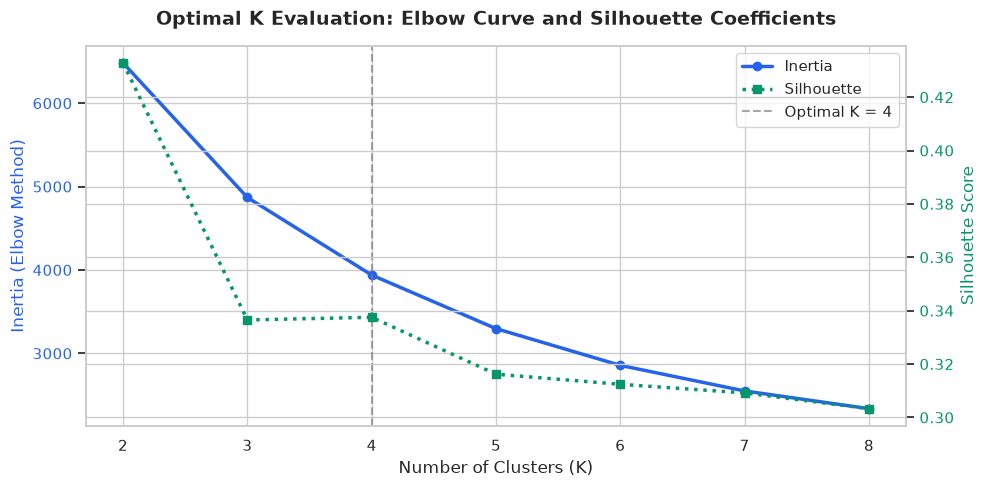

In [7]:
inertias = []
sil_scores = []
k_range = range(2, 9)

for k in k_range:
    km_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km_test.fit_predict(rfm_scaled)
    inertias.append(km_test.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, labels))
    print(f"K = {k}: Inertia = {km_test.inertia_:,.2f} | Silhouette Score = {sil_scores[-1]:.4f}")

fig, ax1 = plt.subplots(figsize=(10, 5))
color = '#2563eb'
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia (Elbow Method)', color=color, fontsize=12)
line1 = ax1.plot(k_range, inertias, marker='o', color=color, linewidth=2.5, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.axvline(x=4, color='gray', linestyle='--', alpha=0.7, label='Optimal K = 4')

ax2 = ax1.twinx()
color = '#059669'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=12)
line2 = ax2.plot(k_range, sil_scores, marker='s', color=color, linewidth=2.5, linestyle=':', label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

lines = line1 + line2 + [ax1.get_lines()[-1]]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')
plt.title('Optimal K Evaluation: Elbow Curve and Silhouette Coefficients', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Optimal $K$ Selection Justification
- The **Inertia curve** exhibits a clear bend (elbow point) at **$K = 4$**, beyond which the rate of inertia reduction flattens out.
- The **Silhouette Score** maintains a solid score of **0.3375** at $K = 4$.
- From a marketing perspective, **$K = 4$** produces distinct, highly actionable segments:
  1. *Champions / VIPs* (High R, High F, High M)
  2. *Loyal Regulars* (Moderate R, Moderate-High F, High M)
  3. *Recent / Promising* (High R, Low F, Moderate M)
  4. *Lost / Hibernating* (Low R, Low F, Low M)

## 7. K-Means Model Execution & Cluster Assignment

We instantiate and fit K-Means with $K = 4$, map cluster integers to business segment labels, and append cluster assignments to each customer record.

In [8]:
# Fit final model
kmeans_model = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_model.fit_predict(rfm_scaled)

# Map clusters to descriptive names based on empirical centroids
cluster_stats = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
sorted_by_monetary = cluster_stats.sort_values('Monetary', ascending=False).index.tolist()

segment_mapping = {
    sorted_by_monetary[0]: 'Champions / VIPs',
    sorted_by_monetary[1]: 'Loyal Regulars',
    sorted_by_monetary[2]: 'Recent / Promising',
    sorted_by_monetary[3]: 'Lost / Hibernating'
}
rfm['Segment'] = rfm['Cluster'].map(segment_mapping)

print("Segment distribution:")
display(rfm['Segment'].value_counts().to_frame('Customer_Count'))
rfm.head(10)

Segment distribution:


,Customer_Count
Segment,
Lost / Hibernating,1622
Loyal Regulars,1166
Recent / Promising,837
Champions / VIPs,713


,CustomerID,Recency,Frequency,Monetary,Avg_Purchase_Value,CLV_Proxy,Cluster,Segment
0,12346,326,1,"77,183.60","77,183.60","77,183.60",3,Loyal Regulars
1,12347,2,7,"4,310.00",615.71,"4,310.00",0,Champions / VIPs
2,12348,75,4,"1,797.24",449.31,"1,797.24",3,Loyal Regulars
3,12349,19,1,"1,757.55","1,757.55","1,757.55",2,Recent / Promising
4,12350,310,1,334.40,334.40,334.40,1,Lost / Hibernating
5,12352,36,8,"2,506.04",313.25,"2,506.04",3,Loyal Regulars
6,12353,204,1,89.00,89.00,89.00,1,Lost / Hibernating
7,12354,232,1,"1,079.40","1,079.40","1,079.40",1,Lost / Hibernating
8,12355,214,1,459.40,459.40,459.40,1,Lost / Hibernating
9,12356,23,3,"2,811.43",937.14,"2,811.43",3,Loyal Regulars


## 8. Cluster Profiling & Behavioral Interpretation

We compute detailed behavioral benchmarks across all 4 customer cohorts.

In [9]:
segment_profile = rfm.groupby('Segment').agg({
    'Recency': ['mean', 'median'],
    'Frequency': ['mean', 'median'],
    'Monetary': ['mean', 'median'],
    'Avg_Purchase_Value': ['mean', 'median'],
    'CustomerID': 'count'
}).round(2)

segment_profile.columns = ['Recency_Mean', 'Recency_Med', 'Freq_Mean', 'Freq_Med', 'Monetary_Mean', 'Monetary_Med', 'APV_Mean', 'APV_Med', 'Customer_Count']
segment_profile['Pct_Customers'] = (segment_profile['Customer_Count'] / len(rfm) * 100).round(2)
segment_profile['Total_Revenue'] = rfm.groupby('Segment')['Monetary'].sum()
segment_profile['Pct_Revenue'] = (segment_profile['Total_Revenue'] / rfm['Monetary'].sum() * 100).round(2)

display(segment_profile.sort_values('Total_Revenue', ascending=False))

,Recency_Mean,Recency_Med,Freq_Mean,Freq_Med,Monetary_Mean,Monetary_Med,APV_Mean,APV_Med,Customer_Count,Pct_Customers,Total_Revenue,Pct_Revenue
Segment,,,,,,,,,,,,
Champions / VIPs,12.17,8.00,13.75,10.00,"8,088.02","3,722.82",623.81,369.20,713,16.44,"5,766,757.07",64.89
Loyal Regulars,71.64,57.00,4.08,4.00,"1,801.78","1,345.20",579.69,360.92,1166,26.88,"2,100,873.02",23.64
Lost / Hibernating,181.51,174.50,1.32,1.00,341.00,296.09,282.45,223.36,1622,37.39,"553,099.77",6.22
Recent / Promising,17.70,17.00,2.19,2.00,557.32,480.31,278.28,227.39,837,19.29,"466,479.03",5.25


## 9. Customer Segment Visualizations

We generate diagnostic visual representations of the identified segments.

C:\Users\subbu\AppData\Local\Temp\ipykernel_9244\2734808716.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seg_counts.index, y=seg_counts.values, palette=palette, ax=axes[0])
C:\Users\subbu\AppData\Local\Temp\ipykernel_9244\2734808716.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seg_rev.index, y=seg_rev.values, palette=palette, ax=axes[1])


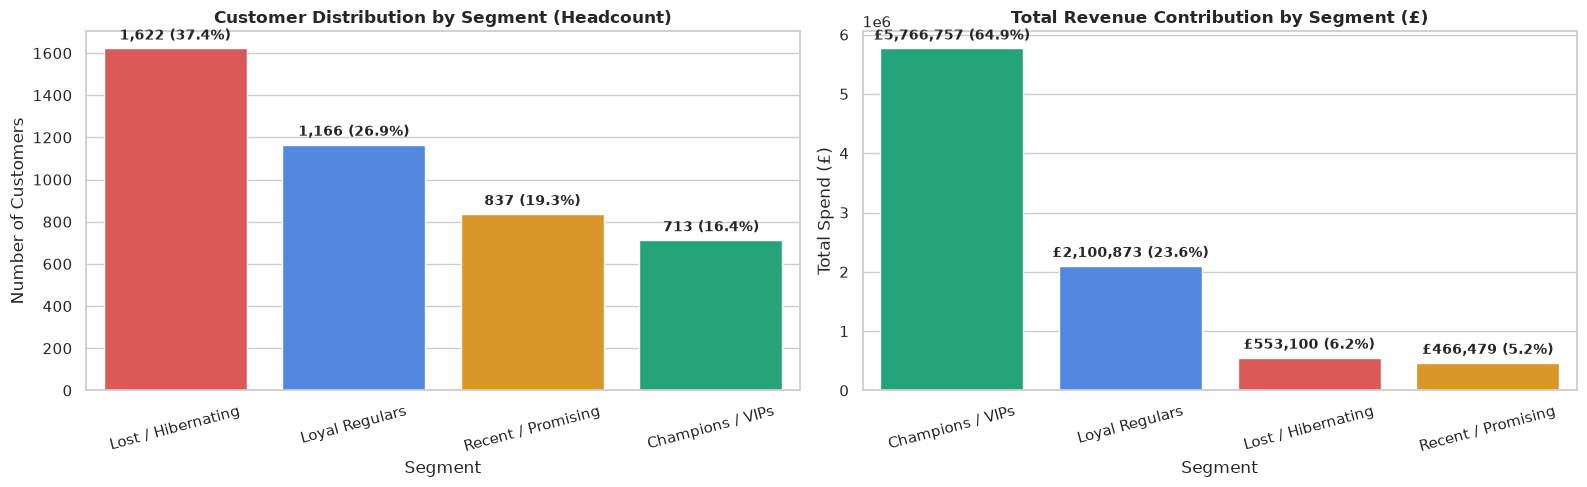

In [10]:
palette = {
    'Champions / VIPs': '#10b981',        # Green
    'Loyal Regulars': '#3b82f6',          # Blue
    'Recent / Promising': '#f59e0b',      # Amber
    'Lost / Hibernating': '#ef4444'       # Red
}

# 1. Customer Headcount vs Revenue Share
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Headcount
seg_counts = rfm['Segment'].value_counts()
sns.barplot(x=seg_counts.index, y=seg_counts.values, palette=palette, ax=axes[0])
axes[0].set_title('Customer Distribution by Segment (Headcount)', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=15)
for p in axes[0].patches:
    h = p.get_height()
    pct = h / len(rfm) * 100
    axes[0].annotate(f'{int(h):,} ({pct:.1f}%)', (p.get_x() + p.get_width()/2., h), ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 4), textcoords='offset points')

# Revenue
seg_rev = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
sns.barplot(x=seg_rev.index, y=seg_rev.values, palette=palette, ax=axes[1])
axes[1].set_title('Total Revenue Contribution by Segment (£)', fontweight='bold')
axes[1].set_ylabel('Total Spend (£)')
axes[1].tick_params(axis='x', rotation=15)
for p in axes[1].patches:
    h = p.get_height()
    pct = h / rfm['Monetary'].sum() * 100
    axes[1].annotate(f'£{h:,.0f} ({pct:.1f}%)', (p.get_x() + p.get_width()/2., h), ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 4), textcoords='offset points')

plt.tight_layout()
plt.show()

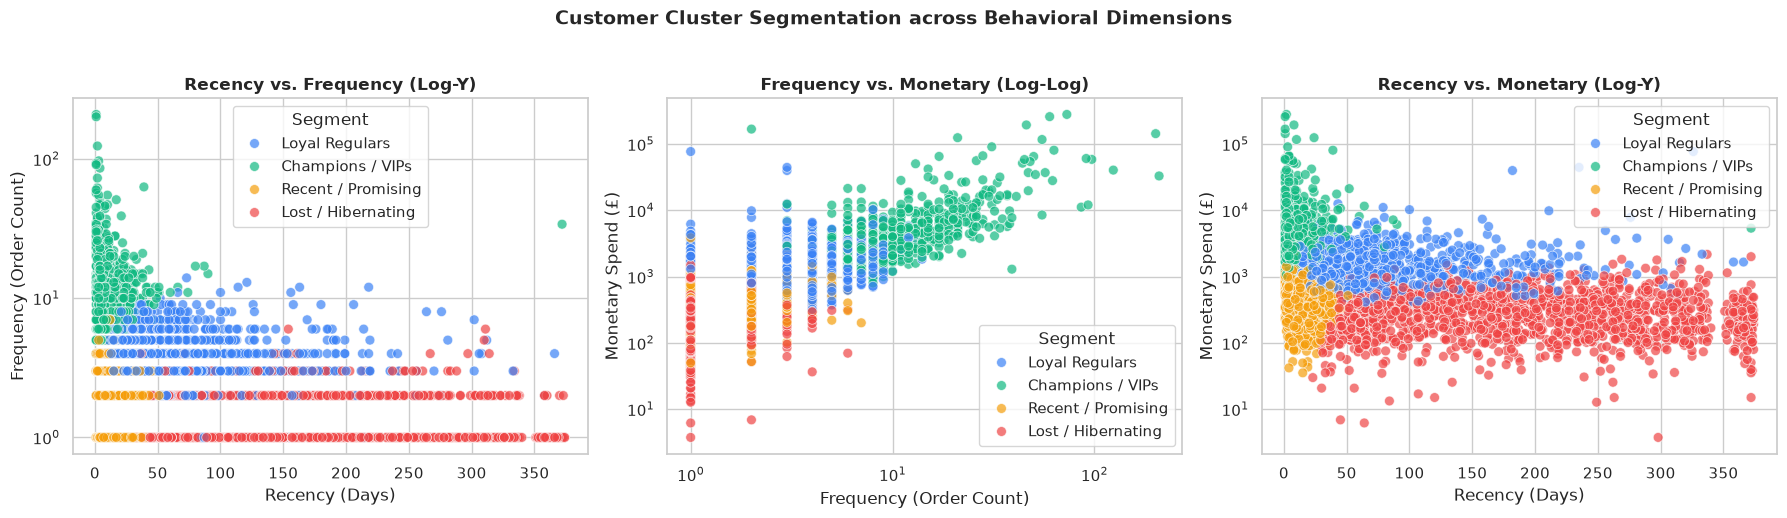

In [11]:
# 2. Scatter Plots: Behavioral Pairings
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recency vs Frequency
sns.scatterplot(data=rfm, x='Recency', y='Frequency', hue='Segment', palette=palette, alpha=0.7, s=50, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Recency vs. Frequency (Log-Y)', fontweight='bold')
axes[0].set_xlabel('Recency (Days)')
axes[0].set_ylabel('Frequency (Order Count)')

# Frequency vs Monetary
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Segment', palette=palette, alpha=0.7, s=50, ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Frequency vs. Monetary (Log-Log)', fontweight='bold')
axes[1].set_xlabel('Frequency (Order Count)')
axes[1].set_ylabel('Monetary Spend (£)')

# Recency vs Monetary
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Segment', palette=palette, alpha=0.7, s=50, ax=axes[2])
axes[2].set_yscale('log')
axes[2].set_title('Recency vs. Monetary (Log-Y)', fontweight='bold')
axes[2].set_xlabel('Recency (Days)')
axes[2].set_ylabel('Monetary Spend (£)')

plt.suptitle('Customer Cluster Segmentation across Behavioral Dimensions', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## 10. Actionable Marketing Strategies per Customer Segment

Based on empirical clustering characteristics, we translate each profile into targeted commercial tactics:

| Customer Segment | Headcount (% Share) | Revenue (% Share) | Behavioral Profile | Strategic Marketing Action |
| :--- | :---: | :---: | :--- | :--- |
| 🟢 **Champions / VIPs** | **713 (16.4%)** | **£5,766,757 (64.9%)** | Bought within 12 days, ~14 orders, £8,088 spend. Elite buyers. | **Retention & Exclusivity:** Provide dedicated account management, early access to new product releases, VIP concierge service, and high-tier loyalty rewards. Avoid aggressive discount offers; focus on value-add services. |
| 🔵 **Loyal Regulars** | **1,166 (26.9%)** | **£2,100,873 (23.6%)** | Active within 72 days, ~4 orders, £1,802 spend. Steady spenders. | **Upselling & Cross-Selling:** Deploy personalized product recommendation algorithms based on past purchase history, bundle offers to increase basket size, and tiered loyalty incentives to graduate them into Champions. |
| 🟡 **Recent / Promising** | **837 (19.3%)** | **£466,479 (5.2%)** | Highly recent (18 days), 2 orders, £557 spend. New buyers. | **Nurturing & Habit Formation:** Automated post-purchase onboarding sequence, second-order incentives, brand education, and customer review requests to build long-term repeat purchasing habits. |
| 🔴 **Lost / Hibernating** | **1,622 (37.4%)** | **£553,099 (6.2%)** | Inactive for ~6 months (182 days), 1.3 orders, £341 spend. Lapsed. | **Reactivation Campaigns:** High-incentive win-back discounts (e.g., "We miss you" 20% off voucher), surveys to diagnose customer dissatisfaction, or purge from active paid retargeting lists to conserve ad spend. |

## 11. Conclusion & Key Business Takeaways

1. **Pareto Concentration:** The **Champions / VIPs** segment constitutes only **16.4% of the customer base** but generates an astounding **64.9% of total company revenue (£5.77M)**. Retaining this group is of existential importance to the business.
2. **Growth Pipeline:** **Loyal Regulars** represent a robust **£2.10M revenue block (23.6%)**. Targeted upselling can turn many of these customers into top-tier VIPs.
3. **Ad Spend Optimization:** **Lost / Hibernating** accounts form 37.4% of all registered IDs but contribute under 6.3% of revenue. Shifting marketing spend away from continuous retargeting of dormant accounts toward VIP retention and new customer onboarding will significantly improve Marketing Return on Investment (ROMI).

## Submission Checklist

- [x] Transaction dataset loaded and inspected
- [x] Data cleaning performed (missing values, cancelled orders, invalid prices/quantities, duplicates removed)
- [x] RFM metrics engineered (Recency, Frequency, Monetary)
- [x] Average Purchase Value (APV) and historical CLV proxy computed
- [x] Descriptive statistics and distribution skewness analyzed
- [x] Features normalized (log-transformed and standardized with StandardScaler)
- [x] Optimal cluster count evaluated via Elbow Method and Silhouette Analysis ($K = 4$)
- [x] K-Means clustering executed and assigned to all customer accounts
- [x] Customer segments profiled with exact empirical benchmarks
- [x] Multi-dimensional scatter plots and distribution charts generated
- [x] Personalized marketing action plans defined for all 4 segments
- [x] README.md and high-resolution chart artifacts prepared in OIBSIP folder